# Intelligent Flight Readiness Prediction System — Initial Data Analysis

### Team Kansas Capstone: Predictive Maintenance for Aircraft Readiness

**Processed by:** Deveshree Mohile                                           
**Dataset:** NASA C-MAPSS Jet Engine Degradation Dataset  
**Phase:** Exploratory Data Analysis (EDA) and Initial Data Processing  
**Date:** March 2026

---

## Project Context

Aircraft engines are complex systems that operate under varying environmental and operational conditions. Over time, internal components degrade, which can eventually lead to performance loss or failure if not detected early.

Airlines rely heavily on sensor data collected from aircraft engines to monitor system health and prevent unexpected failures. Predictive maintenance techniques use this sensor data to estimate the **Remaining Useful Life (RUL)** of engine components and allow maintenance teams to intervene before critical failures occur.

The goal of this project is to develop a **data-driven predictive maintenance system** that can estimate engine health and support better operational decisions for aircraft readiness.

This analysis focuses on the **NASA C-MAPSS dataset**, which provides simulated turbofan engine degradation data widely used in predictive maintenance research.

---

## Why Engine Health Data Matters for This Project

Aircraft operations depend on reliable propulsion systems. Undetected degradation in engine components can lead to:

- Reduced engine efficiency and increased fuel consumption  
- Abnormal pressure or temperature conditions in the engine  
- Increased probability of in-flight mechanical issues  

By analyzing sensor data over time, we can detect patterns that indicate progressive degradation.

Using machine learning models trained on this data, we aim to:

1. Predict **Remaining Useful Life (RUL)** of engines before failure  
2. Identify **sensor indicators of early-stage degradation**  
3. Support **data-driven maintenance planning** to reduce delays and operational disruptions  

This approach directly supports airline goals of improving **safety, cost efficiency, and fleet readiness**.

---

## Dataset Overview: NASA C-MAPSS

The **Commercial Modular Aero-Propulsion System Simulation (C-MAPSS)** dataset is a high-fidelity simulation of turbofan engine degradation developed by NASA.

The dataset provides **multivariate time-series sensor measurements** recorded during engine operation until failure. Each engine is monitored over multiple operational cycles, and sensor readings capture the evolving health of the system.

Four dataset variants are provided, each representing different operational complexities.

| Dataset | Operating Conditions | Fault Modes | Training Engines | Test Engines |
|--------|----------------------|-------------|------------------|--------------|
| FD001 | 1 condition | 1 fault mode | 100 | 100 |
| FD002 | 6 conditions | 1 fault mode | 260 | 259 |
| FD003 | 1 condition | 2 fault modes | 100 | 100 |
| FD004 | 6 conditions | 2 fault modes | 249 | 248 |

For this initial analysis, we focus on **FD001**, which is the simplest configuration and commonly used as a benchmark for Remaining Useful Life prediction.

---

## Dataset Structure

Each row in the dataset represents **one engine at a specific operational cycle**.

The dataset contains:

- **Unit Number:** Unique engine identifier  
- **Cycle:** Engine operating time step  
- **Operational Settings (3):** Engine operating conditions  
- **Sensor Measurements (21):** Indicators of engine health and performance  

| Feature Type | Count | Description |
|--------------|------|-------------|
| Engine Identifier | 1 | Unit number |
| Time Variable | 1 | Cycle number |
| Operational Settings | 3 | Operating conditions |
| Sensors | 21 | Engine health measurements |

---

## Remaining Useful Life (RUL)

To enable predictive maintenance modeling, we compute the **Remaining Useful Life (RUL)** for each engine observation.

RUL represents the number of cycles remaining before the engine reaches failure.

The calculation is:

```
RUL = max_cycle_per_engine - current_cycle
```

This variable becomes the **target variable** used for machine learning models that predict engine health and future failure risk.

---

## Objective of This Notebook

This notebook performs **initial exploratory data analysis (EDA)** on the C-MAPSS dataset to:

- Understand dataset structure and sensor behavior  
- Examine sensor variance and correlations  
- Visualize engine degradation patterns  
- Compute Remaining Useful Life (RUL)  
- Prepare the data for predictive maintenance modeling

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train_FD001.txt to train_FD001.txt


## Step 2: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

### Step 2: Import Required Libraries

In this step, I imported the core Python libraries needed for exploratory data analysis.

- **Pandas** is used for loading and manipulating tabular data.
- **NumPy** is used for numerical operations.
- **Matplotlib** and **Seaborn** are used for data visualization.

I also set the Seaborn style to `"whitegrid"` to make the plots easier to read and visually consistent throughout the analysis.

## Step 3: Define Column Names

In [ ]:
columns = ['unit','cycle','op_setting1','op_setting2','op_setting3']

sensor_cols = [f'sensor{i}' for i in range(1,22)]

columns = columns + sensor_cols

### Step 3: Define Column Names

The C-MAPSS dataset does not include column headers, so I manually assigned names to all columns.

The dataset contains:
- **2 identifier columns**: `unit` and `cycle`
- **3 operational setting columns**: `op_setting1`, `op_setting2`, and `op_setting3`
- **21 sensor columns**: `sensor1` through `sensor21`

Defining these column names makes the dataset easier to interpret and prepares it for downstream analysis and modeling.

## Step 4: Load the Dataset

In [ ]:
train = pd.read_csv(
    "train_FD001.txt",
    sep="\s+",
    header=None
)

train.columns = columns

train.head()

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_210/1394091395.py:3: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",


,unit,cycle,op_setting1,op_setting2,op_setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


### Step 4: Load the Dataset

In this step, I loaded the `train_FD001.txt` file into a Pandas DataFrame.

Since the dataset is space-separated and has no header row, I used:
- `sep="\s+"` to handle variable whitespace between values
- `header=None` because column names were assigned manually afterward

After loading the data, I displayed the first 5 rows to verify that the file was read correctly and that the column names aligned properly with the dataset structure.

The preview confirms that each row represents one engine cycle, with operational settings and sensor measurements recorded at that time step.

**Note:** A syntax warning appeared for `"\s+"`, but the dataset was still loaded correctly. To avoid the warning in future runs, `sep=r"\s+"` can be used instead.

## Step 5: Basic Dataset Info

In [ ]:
print("Dataset Shape:", train.shape)

train.info()

train.describe()
train['unit'].nunique()

Dataset Shape: (20631, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit         20631 non-null  int64  
 1   cycle        20631 non-null  int64  
 2   op_setting1  20631 non-null  float64
 3   op_setting2  20631 non-null  float64
 4   op_setting3  20631 non-null  float64
 5   sensor1      20631 non-null  float64
 6   sensor2      20631 non-null  float64
 7   sensor3      20631 non-null  float64
 8   sensor4      20631 non-null  float64
 9   sensor5      20631 non-null  float64
 10  sensor6      20631 non-null  float64
 11  sensor7      20631 non-null  float64
 12  sensor8      20631 non-null  float64
 13  sensor9      20631 non-null  float64
 14  sensor10     20631 non-null  float64
 15  sensor11     20631 non-null  float64
 16  sensor12     20631 non-null  float64
 17  sensor13     20631 non-null  float64
 18  sensor14     20631 

100

### Step 5: Basic Dataset Overview

This step was used to understand the overall structure and quality of the dataset.

From the output:
- The dataset contains **20,631 rows** and **26 columns**
- There are **100 unique engines**
- All columns have **20,631 non-null values**, indicating that there are no missing values in this training file
- Most columns are numeric and suitable for machine learning and statistical analysis

This means the dataset is clean and complete for exploratory analysis.

Since each row corresponds to one engine at one cycle, the data forms a multivariate time series across multiple engine units.

### Initial Observations

The summary statistics show that the sensor readings operate on very different numeric scales. This is important because it suggests that feature scaling may be needed later before training machine learning models, especially for distance-based or neural network methods.

## Step 6: Compute Remaining Useful Life (RUL)

In [ ]:
max_cycle = train.groupby('unit')['cycle'].max()

train = train.merge(max_cycle.to_frame('max_cycle'), on='unit')

train['RUL'] = train['max_cycle'] - train['cycle']

train.head()

,unit,cycle,op_setting1,op_setting2,op_setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


### Step 6: Compute Remaining Useful Life (RUL)

For the training dataset, each engine is recorded from its initial operation until failure. This allows me to compute the **Remaining Useful Life (RUL)** for every row.

I calculated RUL as:

`RUL = max cycle for each engine - current cycle`

This gives the number of cycles remaining before the engine fails at each point in time.

Adding the `RUL` column is an important step because it creates the target variable for predictive maintenance modeling. It transforms the raw time-series data into a supervised learning problem.

## Step 7: Check Sensor Variance

In [ ]:
sensor_cols = [col for col in train.columns if "sensor" in col]

train[sensor_cols].var().sort_values()

,0
sensor19,0.000000e+00
sensor18,0.000000e+00
sensor16,2.422479e-28
sensor10,2.172333e-25
sensor5,1.152399e-23
sensor1,4.273435e-21
sensor6,1.929279e-06
sensor15,1.406628e-03
sensor8,5.038938e-03
sensor13,5.172330e-03


### Step 7: Analyze Sensor Variance

In this step, I examined the variance of each sensor to identify which sensors are informative and which are nearly constant.

The results show that several sensors have extremely low or zero variance, including:
- `sensor19`
- `sensor18`
- `sensor16`
- `sensor10`
- `sensor5`
- `sensor1`

These sensors change very little across the dataset and are therefore less likely to contribute useful predictive information.

On the other hand, sensors such as:
- `sensor9`
- `sensor14`
- `sensor4`
- `sensor3`

show much higher variance, which suggests they capture more dynamic engine behavior.

This step is useful because low-variance sensors can often be removed during preprocessing to reduce noise and simplify the model.

### Key Insight

The variance analysis suggests that not all 21 sensors are equally useful. Feature selection will likely improve model performance by keeping sensors with meaningful variation and removing near-constant ones.

## Step 8: Plot Engine Lifetime

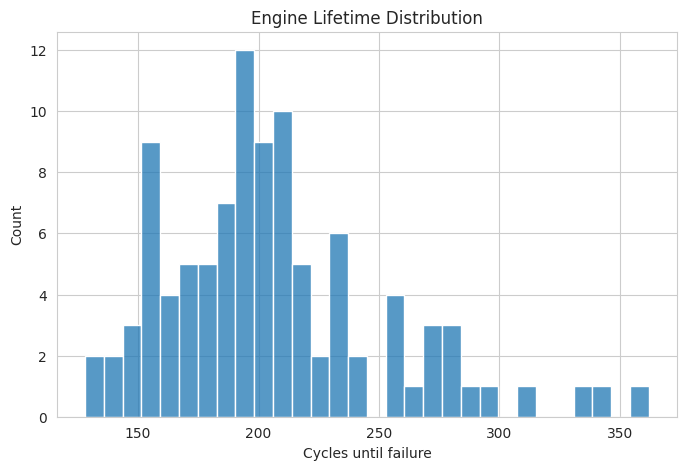

In [ ]:
engine_life = train.groupby('unit')['cycle'].max()

plt.figure(figsize=(8,5))
sns.histplot(engine_life, bins=30)
plt.title("Engine Lifetime Distribution")
plt.xlabel("Cycles until failure")
plt.show()

### Step 8: Distribution of Engine Lifetimes

In this step, I plotted the number of cycles each engine operated before failure.

The histogram shows that engine lifetimes are not identical and vary across units. Most engines appear to fail around the mid-range of the cycle counts, while a smaller number survive significantly longer.

This variation is important because it confirms that the dataset includes different degradation trajectories rather than a fixed lifespan for every engine.

The presence of variability in failure cycles makes the dataset suitable for remaining useful life prediction.

### Observation

Most engine lifetimes are concentrated roughly around the **170 to 230 cycle range**, with a few engines lasting much longer. This indicates a right-skewed distribution with some long-lifetime outliers.

## Step 9: Plot Sensor Degradation

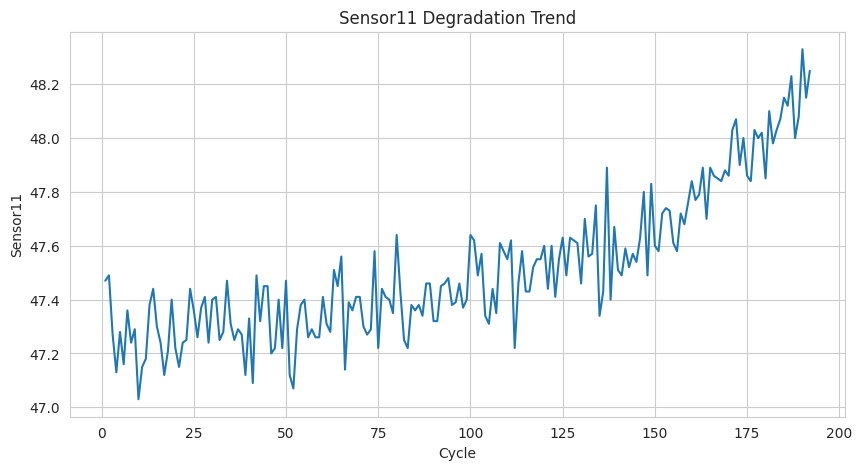

In [ ]:
engine1 = train[train['unit'] == 1]

plt.figure(figsize=(10,5))
plt.plot(engine1['cycle'], engine1['sensor11'])

plt.xlabel("Cycle")
plt.ylabel("Sensor11")
plt.title("Sensor11 Degradation Trend")
plt.show()

### Step 9: Sensor Degradation Trend for One Engine

To understand how sensor values change over time, I plotted `sensor11` across cycles for **engine 1**.

The plot shows that `sensor11` generally increases as the number of cycles grows, although there is some short-term fluctuation. This suggests that the sensor captures a degradation-related pattern rather than random noise alone.

This type of temporal trend is useful for predictive maintenance because it indicates that certain sensors may contain information about engine health and progression toward failure.

### Observation

The upward trend in `sensor11` becomes more noticeable in later cycles, which may indicate that the sensor is sensitive to wear accumulation as the engine approaches failure.

## Step 10: Correlation Heatmap

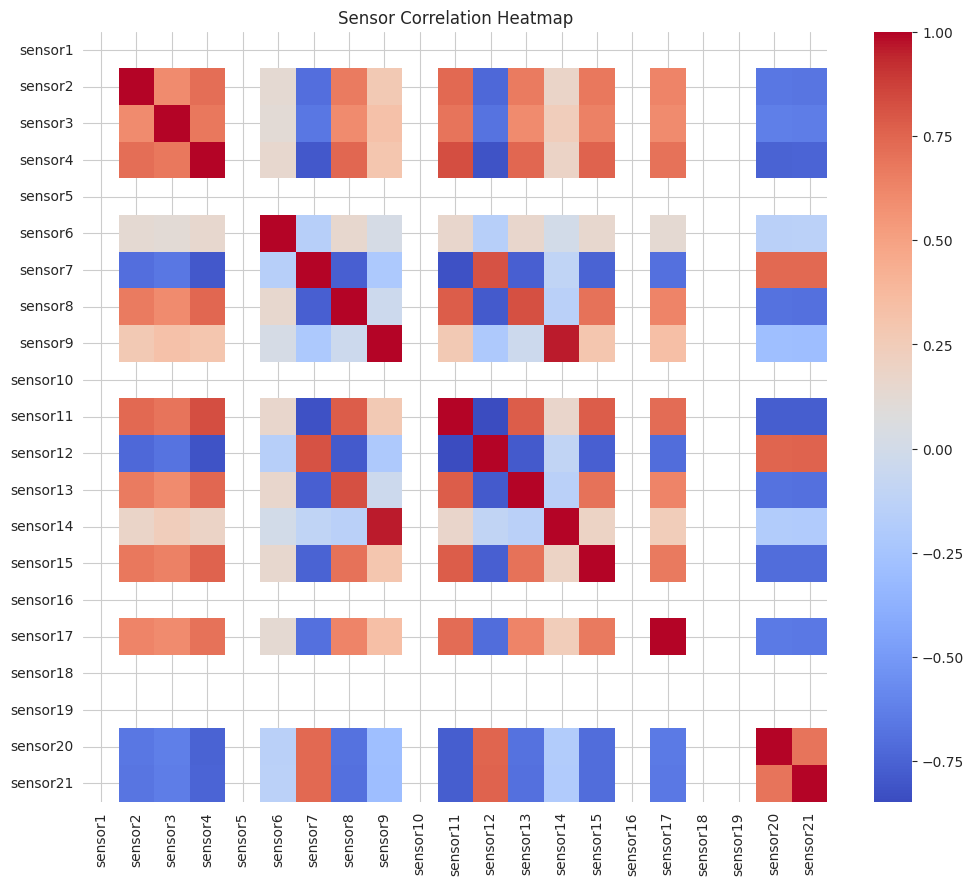

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(train[sensor_cols].corr(), cmap="coolwarm")
plt.title("Sensor Correlation Heatmap")
plt.show()

### Step 10: Sensor Correlation Heatmap

In this step, I analyzed the correlation structure among the sensor variables using a heatmap.

The heatmap reveals that:
- Some sensors are **strongly positively correlated**
- Some sensors are **strongly negatively correlated**
- Several sensor groups appear to move together, suggesting redundancy

This is important because highly correlated sensors may provide overlapping information. Later in the project, this can help guide:
- feature selection
- dimensionality reduction
- interpretation of sensor relationships

Understanding correlation also helps identify which sensors may jointly represent the same degradation process.

### Observation

The heatmap shows clear correlation clusters rather than random patterns. This indicates that engine degradation is reflected through coordinated changes in multiple sensors, not isolated changes in only one variable.

## Step 11: RUL Distribution

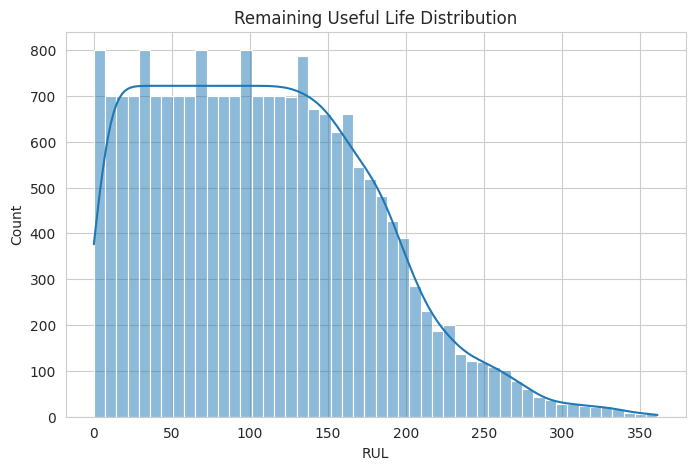

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(train['RUL'], bins=50, kde=True)

plt.title("Remaining Useful Life Distribution")
plt.show()

### Step 11: Distribution of Remaining Useful Life (RUL)

After computing the RUL values, I visualized their distribution using a histogram with a density curve.

The plot shows that RUL values are spread across a wide range, with a larger concentration in the lower and mid-range values. This reflects the fact that the training data includes engine records from early life all the way to failure.

Studying the RUL distribution is important because it helps assess whether the target variable is balanced or skewed. This can influence model design, evaluation, and the potential need for techniques such as RUL capping or transformation.

### Observation

The RUL distribution is not uniform. Lower RUL values are highly represented because every engine contributes many observations as it approaches failure. This is a common pattern in run-to-failure datasets.

## Step 12: Degradation Across Multiple Engines

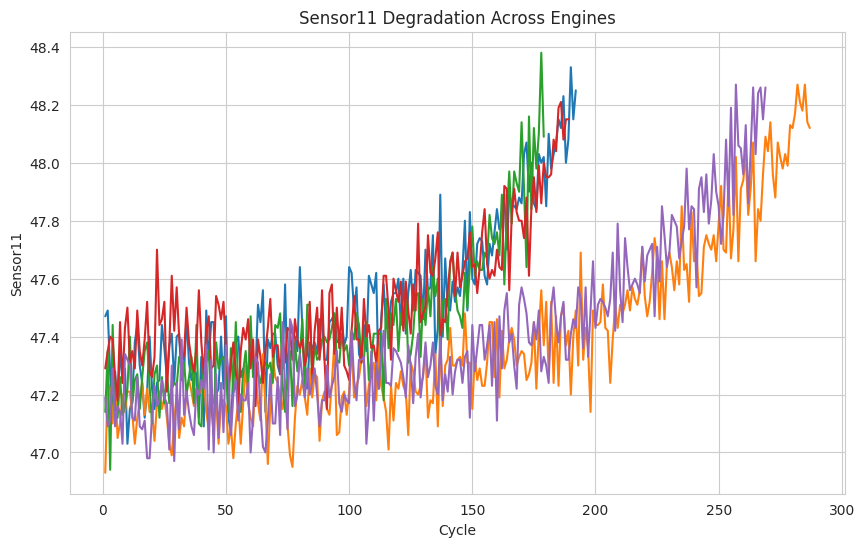

In [ ]:
plt.figure(figsize=(10,6))

for i in range(1,6):
    engine = train[train['unit'] == i]
    plt.plot(engine['cycle'], engine['sensor11'])

plt.title("Sensor11 Degradation Across Engines")
plt.xlabel("Cycle")
plt.ylabel("Sensor11")
plt.show()

### Step 12: Compare Sensor Degradation Across Multiple Engines

In this step, I plotted `sensor11` across cycles for the first five engines to compare degradation behavior across units.

The plot shows that although all engines exhibit a generally increasing trend in `sensor11`, the trajectories are not identical. Each engine has its own pattern, slope, and noise level.

This suggests that engine degradation is not perfectly uniform across units, which makes the prediction task more realistic and challenging.

Comparing multiple engines confirms that the dataset contains both shared degradation behavior and engine-specific variation.

### Key Insight

Since multiple engines show similar overall movement but different detailed trajectories, the model will need to learn both general degradation patterns and variability across units.

## EDA Summary

From this initial exploratory data analysis of the C-MAPSS FD001 training dataset, several important findings emerged:

- The dataset contains **20,631 observations** from **100 engines**
- There are **no missing values**, so the data is clean and ready for preprocessing
- Several sensors have **near-zero variance** and may not be useful for prediction
- Some sensors, such as `sensor11`, show a clear degradation trend over time
- Engine failure cycles vary across units, indicating realistic differences in engine lifespan
- The correlation heatmap shows that several sensors are related, suggesting possible redundancy
- The computed **RUL** provides a meaningful target variable for predictive maintenance modeling

Overall, this EDA confirms that the C-MAPSS dataset is well-suited for building a remaining useful life prediction model and provides a strong foundation for the next steps in preprocessing, feature engineering, and model development.